# Patient Profile Creation

Install required packages

In [1]:
!pip install -q scikit-learn scipy

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import logging
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy import stats

In [3]:
# Configure paths
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1] / "1" / "Features"

# Feature file names
FILES_CONFIG = {
    'laboratory_tests': 'laboratory_tests_features.csv',
    'procedures': 'procedure_code_features.csv',
    'heart_diagnoses': 'heart_diagnoses_features.csv',
    'microbiology': 'microbiology_events_features.csv'
}

print(f"Feature Path: {FEATURE_PATH}")
print(f"Configuration loaded")

Feature Path: /home/gabriele/DAD/project/Tasks/1/Features
Configuration loaded


In [4]:
# Load all feature tables
dfs = {}
for key, filename in FILES_CONFIG.items():
    filepath = FEATURE_PATH / filename
    dfs[key] = pd.read_csv(filepath)
    print(f"\n{key.upper()}")
    print(f"  Shape: {dfs[key].shape}")
    print(f"  Columns: {list(dfs[key].columns)[:5]}...")


LABORATORY_TESTS
  Shape: (4751, 17)
  Columns: ['hadm_id', 'total_tests', 'n_invalid', 'tests_days_span', 'k_max']...

PROCEDURES
  Shape: (3459, 5)
  Columns: ['subject_id', 'hadm_id', 'total_procedures', 'unique_procedures', 'procedures_days_span']...

HEART_DIAGNOSES
  Shape: (4864, 19)
  Columns: ['subject_id', 'hadm_id', 'age', 'gender', 'temperature']...

MICROBIOLOGY
  Shape: (2756, 3)
  Columns: ['subject_id', 'hadm_id', 'infection_severity_score']...


## Data Merging

In [5]:
print("\nHeart Diagnoses + Microbiology")

# Merge heart diagnoses with microbiology
heart_microbiology = pd.merge(
    dfs['heart_diagnoses'],
    dfs['microbiology'],
    on=['subject_id', 'hadm_id'],
    how='outer',
    suffixes=('_heart', '_microbio')
)

print(f" Heart + Microbiology shape: {heart_microbiology.shape}")
print(f"   Unique patients: {heart_microbiology['subject_id'].nunique()}")


Heart Diagnoses + Microbiology
 Heart + Microbiology shape: (5166, 20)
   Unique patients: 4694


In [6]:
print("\nAdd Procedures")

# merge with procedures
heart_micro_procedures = pd.merge(
    heart_microbiology,
    dfs['procedures'],
    on=['subject_id', 'hadm_id'],
    how='outer',
    suffixes=('', '_proc')
)

print(f" Heart + Microbiology + Procedures shape: {heart_micro_procedures.shape}")
print(f"Unique patients: {heart_micro_procedures['subject_id'].nunique()}")


Add Procedures
 Heart + Microbiology + Procedures shape: (5166, 23)
Unique patients: 4694


In [7]:
# Merge with laboratory tests
patient_admissions = pd.merge(
    heart_micro_procedures,
    dfs['laboratory_tests'],
    on='hadm_id',
    how='outer',
    suffixes=('', '_lab')
)

patient_admissions['hadm_id'] = patient_admissions['hadm_id'].astype('Int64')

print(f"  Final merged shape: {patient_admissions.shape}")
print(f"  Unique patients: {patient_admissions['subject_id'].nunique()}")
print(f"  Total admissions: {patient_admissions['hadm_id'].nunique()}")

  Final merged shape: (5166, 39)
  Unique patients: 4694
  Total admissions: 4761


In [8]:
patient_admissions.head()

,subject_id,hadm_id,age,gender,temperature,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,oxygen_saturation,...,na_median,na_n,cl_median,cl_n,creat_max,creat_n,glu_max,glu_n,glu_var,nacl_ratio
0,12869457,20004456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.0,...,137.0,3.0,103.0,3.0,2.7,3.0,193.0,3.0,36.94,1.33
1,13709807,20007905,NaN,NaN,NaN,135.0,62.0,127.0,29.0,93.0,...,134.0,7.0,96.0,7.0,1.3,7.0,314.0,6.0,29.85,1.40
2,19997460,20007905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,134.0,7.0,96.0,7.0,1.3,7.0,314.0,6.0,29.85,1.40
3,19997485,20007905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,134.0,7.0,96.0,7.0,1.3,7.0,314.0,6.0,29.85,1.40
4,12002285,20013519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.0,...,143.0,4.0,106.5,4.0,2.2,4.0,104.0,4.0,13.74,1.35


In [9]:
patient_admissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5166 entries, 0 to 5165
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     5166 non-null   int64  
 1   hadm_id                        5166 non-null   Int64  
 2   age                            1363 non-null   float64
 3   gender                         1363 non-null   float64
 4   temperature                    2426 non-null   float64
 5   bp_systolic                    2383 non-null   float64
 6   bp_diastolic                   2383 non-null   float64
 7   heart_rate                     2255 non-null   float64
 8   respiratory_rate               2178 non-null   float64
 9   oxygen_saturation              3894 non-null   float64
 10  heart_failure_severity_score   1551 non-null   float64
 11  cad_severity_score             2531 non-null   float64
 12  valvular_disease_score         4285 non-null   f

## Aggregation of the features at patient level

In this phase, we aggregate the measure reported at admission level to form a patient-wise report. 

For creating the patient profile, we use aggregation rules for the creation of patient-wise features which aggregates measures taken from patient's admission  

In [10]:
# Categorize features by aggregation method
aggregation_rules = {
    # ========== IDENTIFIERS ==========
    'subject_id': 'first',  # Keep patient ID
    
    # ========== DEMOGRAPHICS (take from any admission) ==========
    'age': 'first',         # Age should be consistent across admissions
    'gender': 'first',      # Gender is constant
    
    # ========== CONTINUOUS FEATURES (worst value) ==========
    # For clinical severity: take WORST value across admissions
    'temperature': 'max',           # Fever = worse
    'bp_systolic': 'mean',          # Average BP more stable
    'bp_diastolic': 'mean',
    'heart_rate': 'max',            # Tachycardia = worse
    'respiratory_rate': 'max',      # Tachypnea = worse
    'oxygen_saturation': 'min',     # Hypoxia = worse (lower is worse)
    
    # ========== COMPOSITE SCORES (worst) ==========
    'heart_failure_severity_score': 'max',
    'cad_severity_score': 'max',
    'valvular_disease_score': 'max',
    'ecg_abnormality_score': 'max',
    'respiratory_distress_score': 'max',
    'exam_abnormality_score': 'max',
    'ct_complications_score': 'max',
    'cardiac_remodeling_score': 'max',
    'stenosis_severity_score': 'max',
    'hemodynamic_instability_score': 'max',
    
    # ========== LABORATORY TESTS (aggregate) ==========
    'total_tests': 'sum',           # Total across all admissions
    'n_invalid': 'sum',             # Total abnormal tests
    'tests_days_span': 'sum',       # Total monitoring days
    'perc_invalid': 'mean',         # Average abnormality rate
    
    # Electrolytes (worst values)
    'k_min': 'min',
    'k_max': 'max',
    'k_n': 'sum',
    'k_abnormal_ratio': 'mean',
    
    'na_min': 'min',
    'na_max': 'max',
    'na_n': 'sum',
    'na_abnormal_ratio': 'mean',
    
    'cl_min': 'min',
    'cl_max': 'max',
    'cl_n': 'sum',
    'cl_abnormal_ratio': 'mean',
    
    'creat_max': 'max',             # Worst kidney function
    'creat_n': 'sum',
    'creat_abnormal_ratio': 'mean',
    
    'glu_max': 'max',               # Worst glucose control
    'glu_n': 'sum',
    'glu_abnormal_ratio': 'mean',
    'glu_var': 'mean',              # Average variability
    
    'na_cl_ratio': 'mean',
    
    # ========== PROCEDURES (aggregate) ==========
    'total_procedures': 'sum',      # Total procedures across admissions
    'unique_procedures': 'sum',     # Sum of unique procedures
    'procedures_days_span': 'sum',
    
    # ========== MICROBIOLOGY (aggregate) ==========
    'infection_severity_score': 'max',     # Worst severity score
    
}

# Count aggregation strategies
agg_counts = pd.Series(aggregation_rules.values()).value_counts()
print("\nAggregation strategy distribution:")
for method, count in agg_counts.items():
    print(f"  • {method}: {count} features")


Aggregation strategy distribution:
  • max: 19 features
  • sum: 11 features
  • mean: 10 features
  • min: 4 features
  • first: 3 features


Now, we apply this aggregation:

In [11]:
# Filter rules to only include columns present in dataset
valid_rules = {col: method for col, method in aggregation_rules.items() 
               if col in patient_admissions.columns}

print(f"\nFeatures to aggregate: {len(valid_rules)}")
print(f"Features not in dataset: {len(aggregation_rules) - len(valid_rules)}")

# Group by patient and aggregate
patient_profiles = patient_admissions.groupby('subject_id').agg(valid_rules).reset_index(drop=True)

print(f"\n Patient-wise aggregation completed")
print(f"   Original shape (admission-level): {patient_admissions.shape}")
print(f"   Aggregated shape (patient-level): {patient_profiles.shape}")
print(f"   Features per patient: {patient_profiles.shape[1]}")


Features to aggregate: 35
Features not in dataset: 12

 Patient-wise aggregation completed
   Original shape (admission-level): (5166, 39)
   Aggregated shape (patient-level): (4694, 35)
   Features per patient: 35


In [12]:
patient_profiles.head()

,subject_id,age,gender,temperature,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,oxygen_saturation,heart_failure_severity_score,...,cl_n,creat_max,creat_n,glu_max,glu_n,glu_var,total_procedures,unique_procedures,procedures_days_span,infection_severity_score
0,10000980,75.0,0.0,36.7,200.0,103.0,65.0,26.0,100.0,3.0,...,9.0,2.3,9.0,163.0,9.0,29.57,7.0,7.0,0.0,0.0
1,10002013,NaN,NaN,37.4,157.0,88.0,118.0,24.0,96.0,NaN,...,2.0,1.0,2.0,395.0,2.0,16.26,2.0,2.0,0.0,NaN
2,10002155,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.0,1.2,16.0,140.0,16.0,10.26,8.0,8.0,14.0,0.0
3,10004457,66.0,1.0,NaN,NaN,NaN,NaN,NaN,98.0,0.0,...,1.0,1.0,1.0,92.0,1.0,NaN,0.0,0.0,0.0,NaN
4,10007058,48.0,1.0,36.8,123.0,71.0,63.0,21.0,99.0,0.0,...,5.0,1.0,5.0,111.0,5.0,7.19,2.0,2.0,0.0,0.0


In [13]:
patient_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4694 entries, 0 to 4693
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     4694 non-null   int64  
 1   age                            1264 non-null   float64
 2   gender                         1264 non-null   float64
 3   temperature                    2277 non-null   float64
 4   bp_systolic                    2239 non-null   float64
 5   bp_diastolic                   2239 non-null   float64
 6   heart_rate                     2130 non-null   float64
 7   respiratory_rate               2064 non-null   float64
 8   oxygen_saturation              3561 non-null   float64
 9   heart_failure_severity_score   1505 non-null   float64
 10  cad_severity_score             2395 non-null   float64
 11  valvular_disease_score         3926 non-null   float64
 12  ecg_abnormality_score          3023 non-null   f

Since `age` and `sex` are clinically essential attributes, it was decided to keep only patients with both present, reducing the number but increasing the quality and interpretability of the patient profiles and subsequent clusters.

In [14]:
patient_profiles = patient_profiles.dropna(subset=['age', 'gender'])
patient_profiles.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1264 entries, 0 to 4287
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     1264 non-null   int64  
 1   age                            1264 non-null   float64
 2   gender                         1264 non-null   float64
 3   temperature                    593 non-null    float64
 4   bp_systolic                    559 non-null    float64
 5   bp_diastolic                   559 non-null    float64
 6   heart_rate                     542 non-null    float64
 7   respiratory_rate               517 non-null    float64
 8   oxygen_saturation              1039 non-null   float64
 9   heart_failure_severity_score   436 non-null    float64
 10  cad_severity_score             697 non-null    float64
 11  valvular_disease_score         1156 non-null   float64
 12  ecg_abnormality_score          805 non-null    float6

## Data Quality Assessment

### Missing values analysis

We calculate missing percentage for each feature

We divide the features into:
- "good" if they have < 20% missing values
- "moderate" if they have a missing rate between 20% and 40%
- "risky" otherwise

In [15]:
# Define thresholds
THRESHOLD_RISKY = 40      # >40% = risky
THRESHOLD_MODERATE = 20   # 20-40% = moderate
# <20% = good

# Missing data analysis
missing_stats = pd.DataFrame({
    'Feature': patient_profiles.columns,
    'Missing_Count': patient_profiles.isnull().sum(),
    'Missing_Pct': (patient_profiles.isnull().sum() / len(patient_profiles) * 100).round(2)
}).sort_values('Missing_Pct', ascending=False)

print(f"  Features with NO missing: {(missing_stats['Missing_Count'] == 0).sum()}")
print(f"  Features with <20% missing: {(missing_stats['Missing_Pct'] < THRESHOLD_MODERATE).sum()}")
print(f"  Features with >40% missing: {(missing_stats['Missing_Pct'] > THRESHOLD_RISKY).sum()}")


  Features with NO missing: 17
  Features with <20% missing: 25
  Features with >40% missing: 9


In [16]:
missing_stats['Category'] = pd.cut(
    missing_stats['Missing_Pct'],
    bins=[-0.1, THRESHOLD_MODERATE, THRESHOLD_RISKY, 100],
    labels=['GOOD', 'MODERATE', 'RISKY']
)

In [17]:
# Show top missing features
print("\nTop 15 features with missing data:")
print(missing_stats[missing_stats['Missing_Count'] > 0].head(15).to_string(index=False))


Top 15 features with missing data:
                     Feature  Missing_Count  Missing_Pct Category
heart_failure_severity_score            828        65.51    RISKY
      ct_complications_score            782        61.87    RISKY
            respiratory_rate            747        59.10    RISKY
                  heart_rate            722        57.12    RISKY
                bp_diastolic            705        55.78    RISKY
                 bp_systolic            705        55.78    RISKY
                 temperature            671        53.09    RISKY
    infection_severity_score            666        52.69    RISKY
          cad_severity_score            567        44.86    RISKY
       ecg_abnormality_score            459        36.31 MODERATE
           oxygen_saturation            225        17.80     GOOD
      valvular_disease_score            108         8.54     GOOD
    cardiac_remodeling_score            108         8.54     GOOD
                     glu_var            

### Features removal

We can delete the "risky" features which have a lot of missing values because they are not informative to us at patient level. 

In [18]:
exclude_features = ['subject_id', 'hadm_id', 'dod']

In [19]:
good_features = missing_stats[
    (missing_stats['Category'] == 'GOOD') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

moderate_features = missing_stats[
    (missing_stats['Category'] == 'MODERATE') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

risky_features = missing_stats[
    (missing_stats['Category'] == 'RISKY') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

In [20]:
critical_features = [
    'heart_rate', 'bp_systolic', 'bp_diastolic', 
    'respiratory_rate', 'temperature', 'oxygen_saturation',
    'age', 'gender' 
]

severity_threshold = 50.0
severity_cols = [col for col in missing_stats['Feature'] 
                 if 'score' in col.lower()]

# Separa severity scores in "tenibili" e "da rimuovere"
keep_severity = missing_stats[
    (missing_stats['Feature'].isin(severity_cols)) & 
    (missing_stats['Missing_Pct'] < severity_threshold)
]['Feature'].tolist()

remove_severity = missing_stats[
    (missing_stats['Feature'].isin(severity_cols)) & 
    (missing_stats['Missing_Pct'] >= severity_threshold)
]['Feature'].tolist()

# Feature di laboratorio/procedure: soglia più permissiva (60%)
lab_threshold = 60.0
lab_features = [col for col in patient_profiles.columns 
                if any(x in col for x in ['glu', 'creat', 'na', 'cl', 'k'])]

keep_lab = missing_stats[
    (missing_stats['Feature'].isin(lab_features)) & 
    (missing_stats['Missing_Pct'] < lab_threshold)
]['Feature'].tolist()

# LISTA FINALE
features_to_keep = list(set(
    critical_features + 
    keep_severity + 
    keep_lab + 
    good_features +  # Dalla tua analisi precedente
    moderate_features  # Dalla tua analisi precedente
))

features_to_remove = remove_severity + [
    col for col in patient_profiles.columns 
    if col not in features_to_keep and col != 'subject_id'
]

In [21]:
df_filtered = patient_profiles[['subject_id'] + features_to_keep].copy()

### Handling missing values on moderate and good features

### Missingness indicators creation

In [22]:
vital_signs = ['heart_rate', 'bp_systolic', 'bp_diastolic', 
               'respiratory_rate', 'temperature']

for vital in vital_signs:
    if vital in df_filtered.columns:
        # 1 = measured, 0 = otherwise
        indicator_name = f'{vital}_measured'
        df_filtered[indicator_name] = (~df_filtered[vital].isnull()).astype(int)
        
        missing_pct = df_filtered[vital].isnull().mean() * 100
        measured_pct = 100 - missing_pct
        print(f"{indicator_name}: {measured_pct:.1f}% patients measured")

heart_rate_measured: 42.9% patients measured
bp_systolic_measured: 44.2% patients measured
bp_diastolic_measured: 44.2% patients measured
respiratory_rate_measured: 40.9% patients measured
temperature_measured: 46.9% patients measured


#### Identify feature types (binary vs continuous)

In [23]:
binary_features = []
continuous_features = []

for col in features_to_keep:
    if col in df_filtered.columns:
        # Check unique non-null values
        unique_vals = df_filtered[col].dropna().unique()
        
        # Binary: only 0 and 1 (or True/False)
        if len(unique_vals) <= 2:
            if all(v in [0, 1, 0.0, 1.0, True, False] for v in unique_vals):
                binary_features.append(col)
            else:
                continuous_features.append(col)
        else:
            continuous_features.append(col)

In [24]:
print("\n   Continuous features (sample):")
for feat in continuous_features[:10]:
    n_missing = df_filtered[feat].isnull().sum()
    print(f"      • {feat:<40} {n_missing} missing")
if len(continuous_features) > 10:
    print(f"      ... and {len(continuous_features)-10} more")


   Continuous features (sample):
      • cl_n                                     0 missing
      • respiratory_distress_score               0 missing
      • unique_procedures                        0 missing
      • glu_var                                  102 missing
      • cad_severity_score                       567 missing
      • procedures_days_span                     0 missing
      • glu_n                                    0 missing
      • tests_days_span                          0 missing
      • temperature                              671 missing
      • creat_n                                  0 missing
      ... and 20 more


Now we can impute missing values.

Let's start from binary features...

In [25]:
binary_imputation_log = []

for col in binary_features:
    if col in df_filtered.columns:
        n_missing = df_filtered[col].isnull().sum()
        
        if n_missing > 0:
            # Calculate mode
            mode_val = df_filtered[col].mode()[0] if not df_filtered[col].mode().empty else 0
            
            # Impute
            df_filtered[col].fillna(mode_val, inplace=True)
            
            binary_imputation_log.append({
                'Feature': col,
                'Missing_Count': n_missing,
                'Imputed_Value': mode_val
            })
            
            print(f"{col:<40} {n_missing:>4} missing → {int(mode_val)}")

print(f"\nImputed {len(binary_imputation_log)} binary features")


Imputed 0 binary features


And continue with continuous features: we use KNN imputer if there is possibility, otherwise we use median fallback

In [26]:
from sklearn.impute import KNNImputer


if len(continuous_features) > 0:
    continuous_data = df_filtered[continuous_features].copy()
    for col in continuous_data.columns:
        if continuous_data[col].dtype == 'object':
            try:
                continuous_data[col] = pd.to_numeric(continuous_data[col])
            except:
                continuous_features.remove(col)
    
    missing_before = continuous_data.isnull().sum()
    features_with_missing = missing_before[missing_before > 0]
    
    print(f"Features requiring imputation: {len(features_with_missing)}\n")
    
    # KNN Imputation
    knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
    
    try:
        continuous_imputed = knn_imputer.fit_transform(continuous_data)
        
        # Update dataframe
        df_filtered[continuous_features] = continuous_imputed
        
        # Log imputation
        for feat in features_with_missing.index:
            print(f"  ✓ {feat:<40} {missing_before[feat]:>4} missing → KNN imputed")
        
        print(f"\nKNN imputation completed for {len(features_with_missing)} continuous features")
        print(f"   Method: k=5 nearest neighbors with distance weighting")
        
    except Exception as e:
        print(f"\nKNN imputation failed: {str(e)}")
        print("   Falling back to median imputation...")
        
        # Fallback: median imputation
        for col in continuous_features:
            if df_filtered[col].isnull().any():
                median_val = df_filtered[col].median()
                df_filtered[col].fillna(median_val, inplace=True)
                print(f"  ✓ {col:<40} imputed with median: {median_val:.2f}")
else:
    print("No continuous features requiring imputation")

Features requiring imputation: 15

  ✓ glu_var                                   102 missing → KNN imputed
  ✓ cad_severity_score                        567 missing → KNN imputed
  ✓ temperature                               671 missing → KNN imputed
  ✓ ecg_abnormality_score                     459 missing → KNN imputed
  ✓ k_max                                       5 missing → KNN imputed
  ✓ glu_max                                     8 missing → KNN imputed
  ✓ respiratory_rate                          747 missing → KNN imputed
  ✓ oxygen_saturation                         225 missing → KNN imputed
  ✓ valvular_disease_score                    108 missing → KNN imputed
  ✓ heart_rate                                722 missing → KNN imputed
  ✓ bp_systolic                               705 missing → KNN imputed
  ✓ creat_max                                   5 missing → KNN imputed
  ✓ k_min                                       5 missing → KNN imputed
  ✓ bp_diastolic             

In [27]:
imputed_df = pd.DataFrame(
    continuous_imputed, 
    columns=continuous_features,
    index=continuous_data.index
)

for col in continuous_features:
    non_null_values = continuous_data[col].dropna()
    if len(non_null_values) > 0:
        decimals = non_null_values.apply(
            lambda x: len(str(x).split('.')[-1]) if '.' in str(x) else 0
        ).max()
        decimals = min(decimals, 3)
        imputed_df[col] = imputed_df[col].round(decimals)

df_filtered[continuous_features] = imputed_df


In [28]:
patient_profiles = df_filtered.copy()

## Dimensionality Reduction

In [29]:
numeric_cols = patient_profiles.select_dtypes(include='number').columns
features_cols = [col for col in numeric_cols if col not in ['subject_id']]

In [30]:
# Create working dataframe
X = patient_profiles[features_cols].copy()

In [31]:
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.01)
sel.fit(X)
low_variance_features = X.columns[~sel.get_support()].tolist()
print(f"\nLow variance features removed ({len(low_variance_features)}): {low_variance_features}")

X = X.loc[:, sel.get_support()]
print(f"After variance filter: {X.shape[1]} features")



Low variance features removed (0): []
After variance filter: 36 features


In [32]:
import numpy as np
corr_matrix = X.corr()
print(f"Correlation matrix: {corr_matrix.shape}")

Correlation matrix: (36, 36)


In [33]:
# Find High correlation feature pairs
def find_high_correlations(corr_matrix, threshold=0.8):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr_pairs.append({
                    'feature_1': corr_matrix.columns[i],
                    'feature_2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)

In [34]:
high_corr = find_high_correlations(corr_matrix, threshold=0.8)
print(high_corr)

               feature_1                  feature_2  correlation
33  bp_systolic_measured      bp_diastolic_measured     1.000000
6                   cl_n                       na_n     0.999422
26                   k_n                       na_n     0.998588
3                   cl_n                        k_n     0.998242
20               creat_n                        k_n     0.996396
23               creat_n                       na_n     0.996062
2                   cl_n                    creat_n     0.995940
7      unique_procedures           total_procedures     0.990271
13                 glu_n                total_tests     0.965760
27             n_invalid                total_tests     0.959169
15       tests_days_span                    creat_n     0.938652
16       tests_days_span                        k_n     0.937000
1                   cl_n            tests_days_span     0.935943
19       tests_days_span                       na_n     0.935339
25                   k_n 

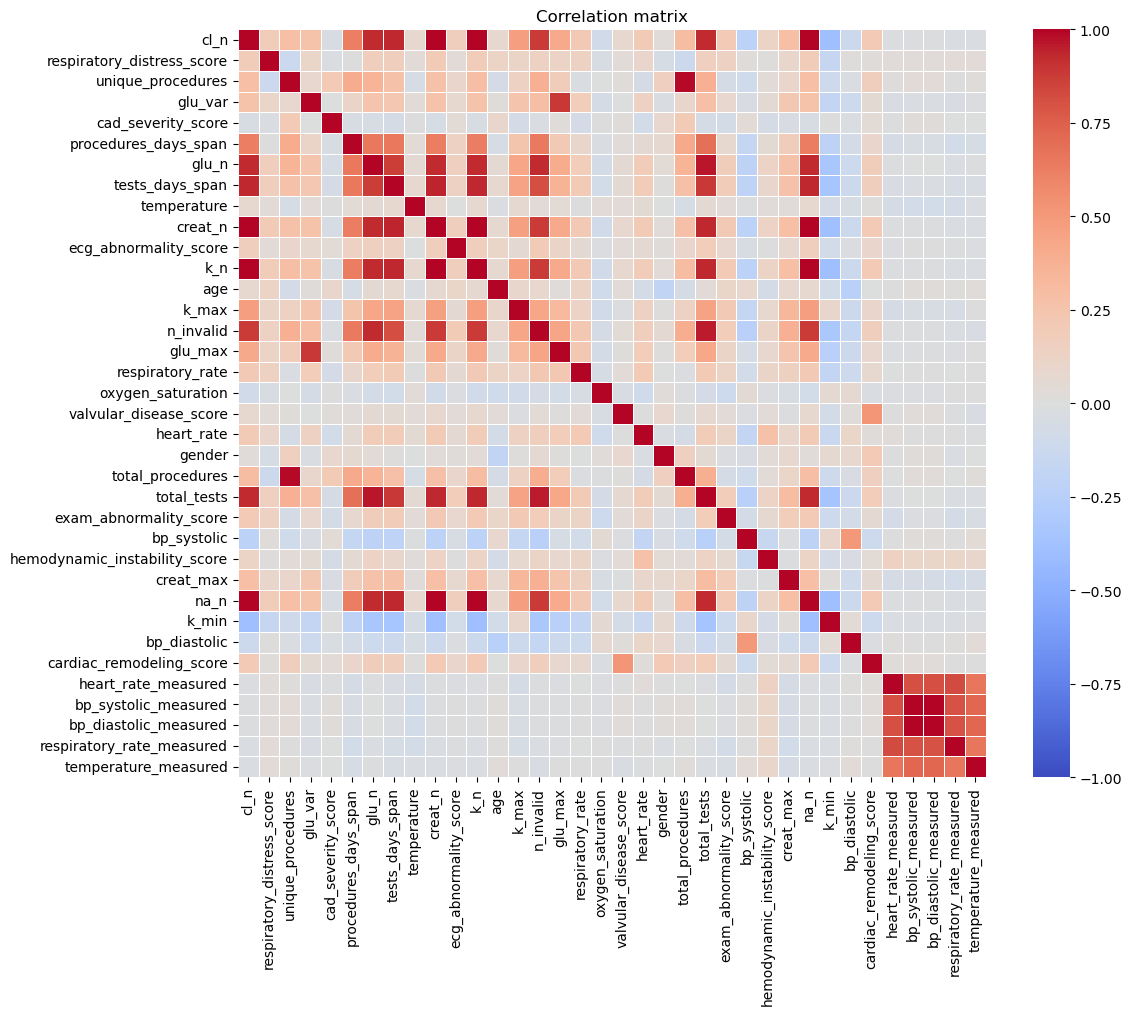

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap base
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=False,  
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()


As we can see, there are lot of redundant features, so we have to choose which ones to keep and which ones to discard.

In [36]:
high_corr = find_high_correlations(corr_matrix, threshold=0.80)
print(f"Highly correlated pairs found (r > 0.80): {len(high_corr)}")

Highly correlated pairs found (r > 0.80): 34


In [37]:
from collections import defaultdict

corr_groups = defaultdict(set)
for feat1, feat2, corr_val in high_corr.itertuples(index=False):
    group_key = min(feat1, feat2)  
    corr_groups[group_key].add(feat1)
    corr_groups[group_key].add(feat2)

features_to_remove = set()

for group_key, group_features in corr_groups.items():
    if len(group_features) <= 1:
        continue
    
    variances = {feat: X[feat].var() for feat in group_features if feat in X.columns}
    sorted_by_var = sorted(variances.items(), key=lambda x: x[1], reverse=True)
    keep_feature = sorted_by_var[0][0]
    remove_features = [f for f, _ in sorted_by_var[1:]]
    
    features_to_remove.update(remove_features)
    
    print(f"\Correlated groups:")
    for feat, var in sorted_by_var:
        status = "✓ KEEP" if feat == keep_feature else "✗ REMOVE"
        print(f"  {status} {feat:40} (var={var:.3f})")

print(f"\n{'='*60}")
print(f"Features to remove: {len(features_to_remove)}")
print(f"Final features: {X.shape[1] - len(features_to_remove)}")

X = X.drop(columns=list(features_to_remove), errors='ignore')



Gruppo correlato:
  ✓ KEEP bp_diastolic_measured                    (var=0.247)
  ✗ REMOVE bp_systolic_measured                     (var=0.247)
  ✗ REMOVE heart_rate_measured                      (var=0.245)

Gruppo correlato:
  ✓ KEEP total_tests                              (var=38172.295)
  ✗ REMOVE n_invalid                                (var=8598.663)
  ✗ REMOVE glu_n                                    (var=82.959)
  ✗ REMOVE k_n                                      (var=64.525)
  ✗ REMOVE na_n                                     (var=64.117)
  ✗ REMOVE cl_n                                     (var=63.733)
  ✗ REMOVE creat_n                                  (var=62.163)
  ✗ REMOVE tests_days_span                          (var=21.187)

Gruppo correlato:
  ✓ KEEP total_tests                              (var=38172.295)
  ✗ REMOVE n_invalid                                (var=8598.663)
  ✗ REMOVE k_n                                      (var=64.525)
  ✗ REMOVE na_n                 

In [38]:
final_features = ['subject_id'] + X.columns.tolist()
patient_profiles_clean = patient_profiles[final_features].copy()

In [39]:
missing_counts = patient_profiles_clean.isna().sum()
missing_pct = (missing_counts / len(patient_profiles_clean) * 100).round(2)
missing_df = pd.DataFrame({
    'Feature': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Pct': missing_pct.values
}).sort_values('Missing_Pct', ascending=False)

In [40]:
missing_df[missing_df['Missing_Pct'] > 0].shape

(0, 3)

In [41]:
missing_df[missing_df['Missing_Pct'] > 0].head(15)

,Feature,Missing_Count,Missing_Pct


## Final dataset statistics

In [42]:
print("\n=== FINAL DATASET STATISTICS ===")

print(f"\n Patient Coverage:")
print(f"   Total unique patients: {patient_profiles['subject_id'].nunique()}")
print(f"   Complete cases (no missing): {patient_profiles.dropna().shape[0]}")

# Numeric summary
numeric_final = patient_profiles_clean.select_dtypes(include=[np.number])

print(f"\nNumeric Features Summary:")
summary_stats = numeric_final.describe().round(3)
print(summary_stats.iloc[[1, 2, 3, 4, 5, 7]].T.head(15))


=== FINAL DATASET STATISTICS ===

 Patient Coverage:
   Total unique patients: 1264
   Complete cases (no missing): 1264

Numeric Features Summary:
                                    mean          std         min  \
subject_id                  1.493320e+07  2879456.811  10000980.0   
respiratory_distress_score  1.270000e+00        1.244         0.0   
cad_severity_score          1.874000e+00        1.364         0.0   
procedures_days_span        9.580000e-01        3.220         0.0   
temperature                 3.691000e+01        1.486        30.0   
ecg_abnormality_score       1.402000e+00        1.343         0.0   
age                         6.883600e+01       14.949        18.0   
k_max                       4.636000e+00        0.630         3.1   
glu_max                     1.610980e+02       73.791        46.0   
respiratory_rate            1.895400e+01        2.291        10.0   
oxygen_saturation           9.685700e+01        2.228        85.0   
valvular_disease_score 

### patient-wise features transformation

Before applying the transformations to the final patient-wise variables, we need to analyze their distribution to better understand what type of trasnformation they need.

In [43]:
columns_final = numeric_final.columns
features_cols = [c for c in columns_final if c != 'subject_id']
features_cols

['respiratory_distress_score',
 'cad_severity_score',
 'procedures_days_span',
 'temperature',
 'ecg_abnormality_score',
 'age',
 'k_max',
 'glu_max',
 'respiratory_rate',
 'oxygen_saturation',
 'valvular_disease_score',
 'heart_rate',
 'gender',
 'total_procedures',
 'total_tests',
 'exam_abnormality_score',
 'bp_systolic',
 'hemodynamic_instability_score',
 'creat_max',
 'k_min',
 'bp_diastolic',
 'cardiac_remodeling_score',
 'bp_diastolic_measured',
 'temperature_measured']

We divide the features we have for clinical purposes: 


In [44]:
feature_groups = {
    # 1. Demographics & Patient Characteristics
    "Demographics": [
        "age",
        "gender"
    ],
    
    # 2. Vital Signs & Physical Monitoring
    "Vital Signs": [
        "temperature",
        "bp_systolic",
        "bp_diastolic",
        "heart_rate",
        "respiratory_rate",
        "oxygen_saturation"
    ],
    
    # 3. Cardiac Disease Severity Scores
    "Cardiac Severity": [
        "cad_severity_score",              # Coronary Artery Disease
        "valvular_disease_score",
        "cardiac_remodeling_score",
        "hemodynamic_instability_score",
        "ecg_abnormality_score"
    ],
    
    # 4. Respiratory & Systemic Distress
    "Respiratory & Systemic": [
        "respiratory_distress_score",
        "exam_abnormality_score"
    ],
    
    # 5. Laboratory Metabolic Markers
    "Metabolic Markers": [
        "glu_max",                         # Glucose (diabetes/stress)
        "k_max",                           # Potassium
        "k_min",
        "creat_max"                        # Creatinine (kidney function)
    ],
    
    # 6. Clinical Complexity & Interventions
    "Clinical Complexity": [
        "total_tests",
        "total_procedures",
        "procedures_days_span"
    ],
    
    # 7. Monitoring Indicators (Binary)
    "Monitoring Indicators": [
        "bp_diastolic_measured",
        "temperature_measured"
    ]
}

Now we can visualize the distributions of the clinical features groups

/tmp/ipykernel_13185/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


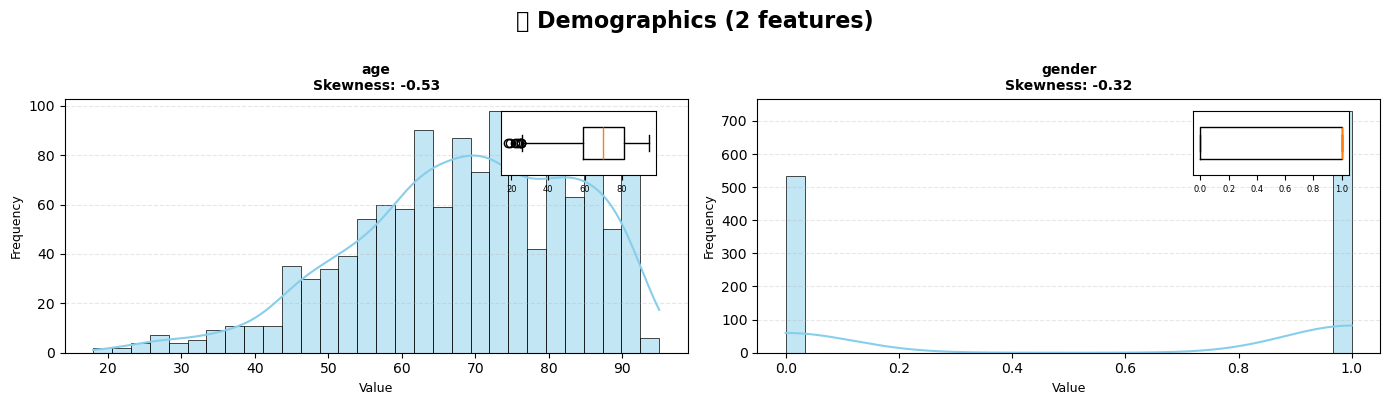


Group: Demographics

age:
  • N values: 1264
  • Range: [18.00, 95.00]
  • Mean: 68.84 ± 14.95
  • Median: 70.00
  • Skewness: -0.53
  • % NaN: 0.0%

gender:
  • N values: 1264
  • Range: [0.00, 1.00]
  • Mean: 0.58 ± 0.49
  • Median: 1.00
  • Skewness: -0.32
  • % NaN: 0.0%




/tmp/ipykernel_13185/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


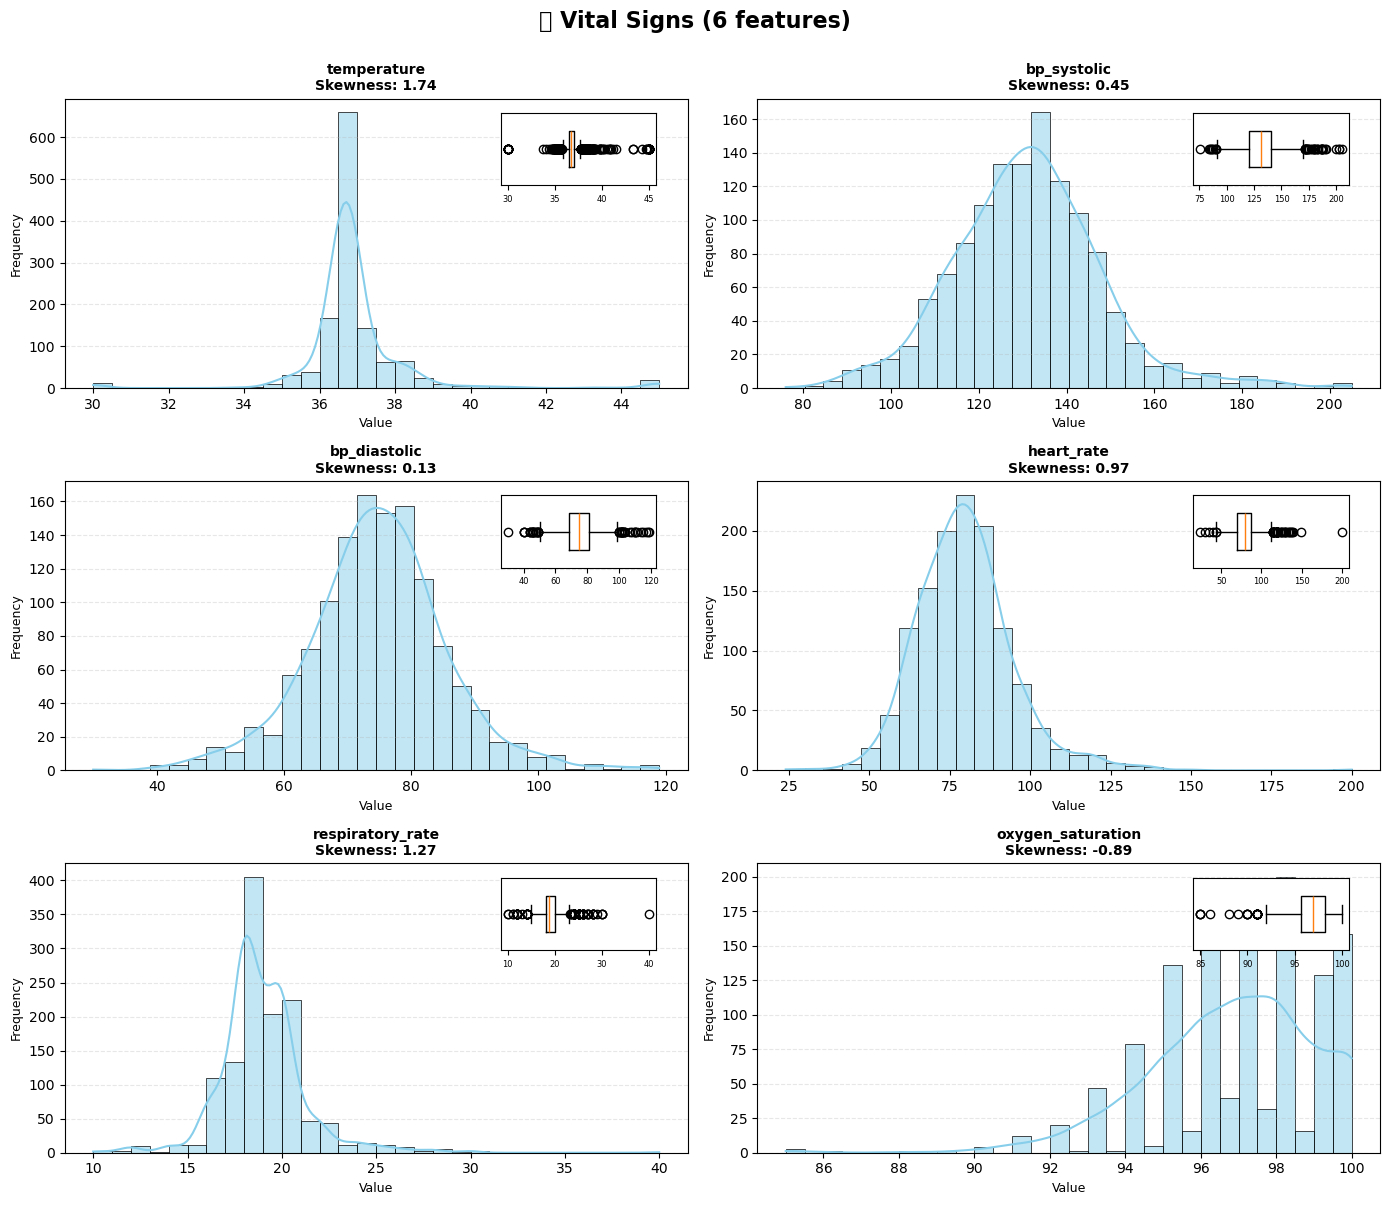


Group: Vital Signs

temperature:
  • N values: 1264
  • Range: [30.00, 45.00]
  • Mean: 36.91 ± 1.49
  • Median: 36.70
  • Skewness: 1.74
  • % NaN: 0.0%

bp_systolic:
  • N values: 1264
  • Range: [76.00, 205.00]
  • Mean: 131.07 ± 16.95
  • Median: 131.05
  • Skewness: 0.45
  • % NaN: 0.0%

bp_diastolic:
  • N values: 1264
  • Range: [30.00, 119.00]
  • Mean: 74.75 ± 10.87
  • Median: 74.90
  • Skewness: 0.13
  • % NaN: 0.0%

heart_rate:
  • N values: 1264
  • Range: [24.00, 200.00]
  • Mean: 79.77 ± 15.12
  • Median: 79.00
  • Skewness: 0.97
  • % NaN: 0.0%

respiratory_rate:
  • N values: 1264
  • Range: [10.00, 40.00]
  • Mean: 18.95 ± 2.29
  • Median: 18.70
  • Skewness: 1.27
  • % NaN: 0.0%

oxygen_saturation:
  • N values: 1264
  • Range: [85.00, 100.00]
  • Mean: 96.86 ± 2.23
  • Median: 97.00
  • Skewness: -0.89
  • % NaN: 0.0%




/tmp/ipykernel_13185/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


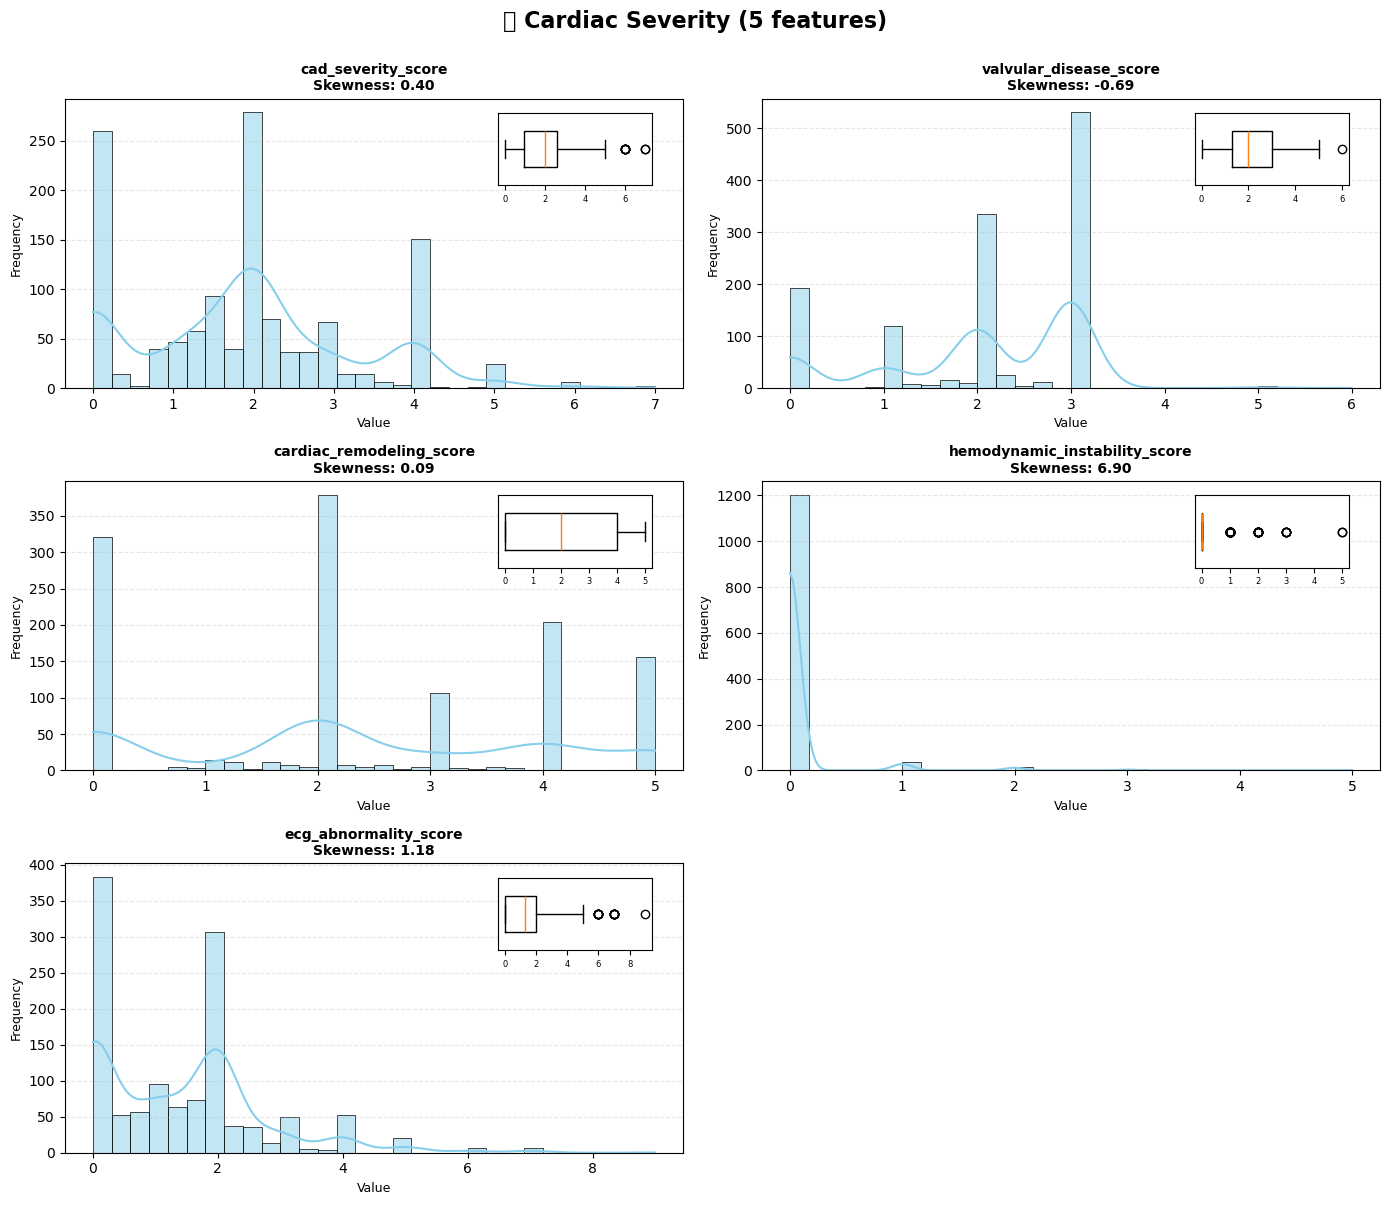


Group: Cardiac Severity

cad_severity_score:
  • N values: 1264
  • Range: [0.00, 7.00]
  • Mean: 1.87 ± 1.36
  • Median: 2.00
  • Skewness: 0.40
  • % NaN: 0.0%

valvular_disease_score:
  • N values: 1264
  • Range: [0.00, 6.00]
  • Mean: 2.03 ± 1.09
  • Median: 2.00
  • Skewness: -0.69
  • % NaN: 0.0%

cardiac_remodeling_score:
  • N values: 1264
  • Range: [0.00, 5.00]
  • Mean: 2.26 ± 1.69
  • Median: 2.00
  • Skewness: 0.09
  • % NaN: 0.0%

hemodynamic_instability_score:
  • N values: 1264
  • Range: [0.00, 5.00]
  • Mean: 0.08 ± 0.39
  • Median: 0.00
  • Skewness: 6.90
  • % NaN: 0.0%

ecg_abnormality_score:
  • N values: 1264
  • Range: [0.00, 9.00]
  • Mean: 1.40 ± 1.34
  • Median: 1.30
  • Skewness: 1.18
  • % NaN: 0.0%




/tmp/ipykernel_13185/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


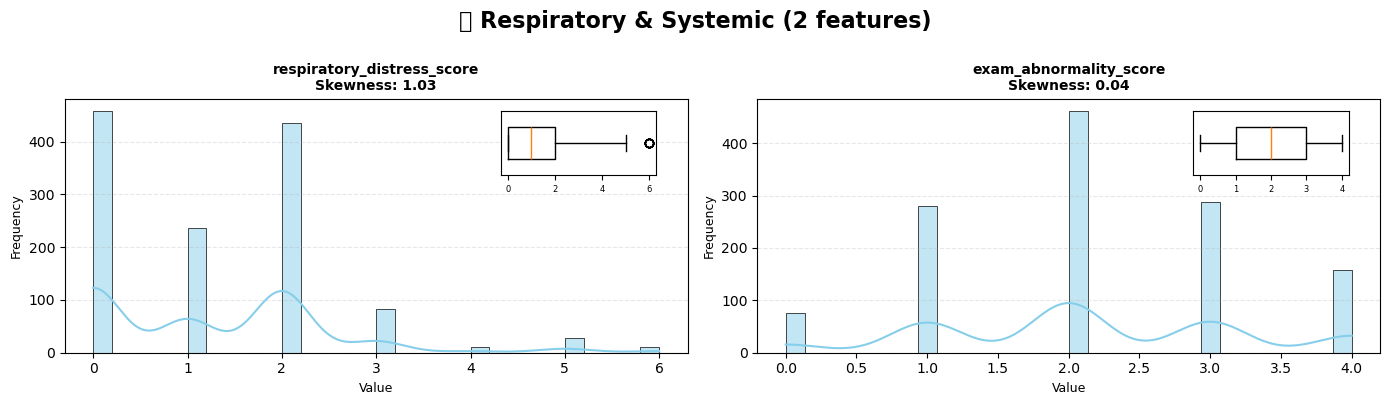


Group: Respiratory & Systemic

respiratory_distress_score:
  • N values: 1264
  • Range: [0.00, 6.00]
  • Mean: 1.27 ± 1.24
  • Median: 1.00
  • Skewness: 1.03
  • % NaN: 0.0%

exam_abnormality_score:
  • N values: 1264
  • Range: [0.00, 4.00]
  • Mean: 2.14 ± 1.08
  • Median: 2.00
  • Skewness: 0.04
  • % NaN: 0.0%




/tmp/ipykernel_13185/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


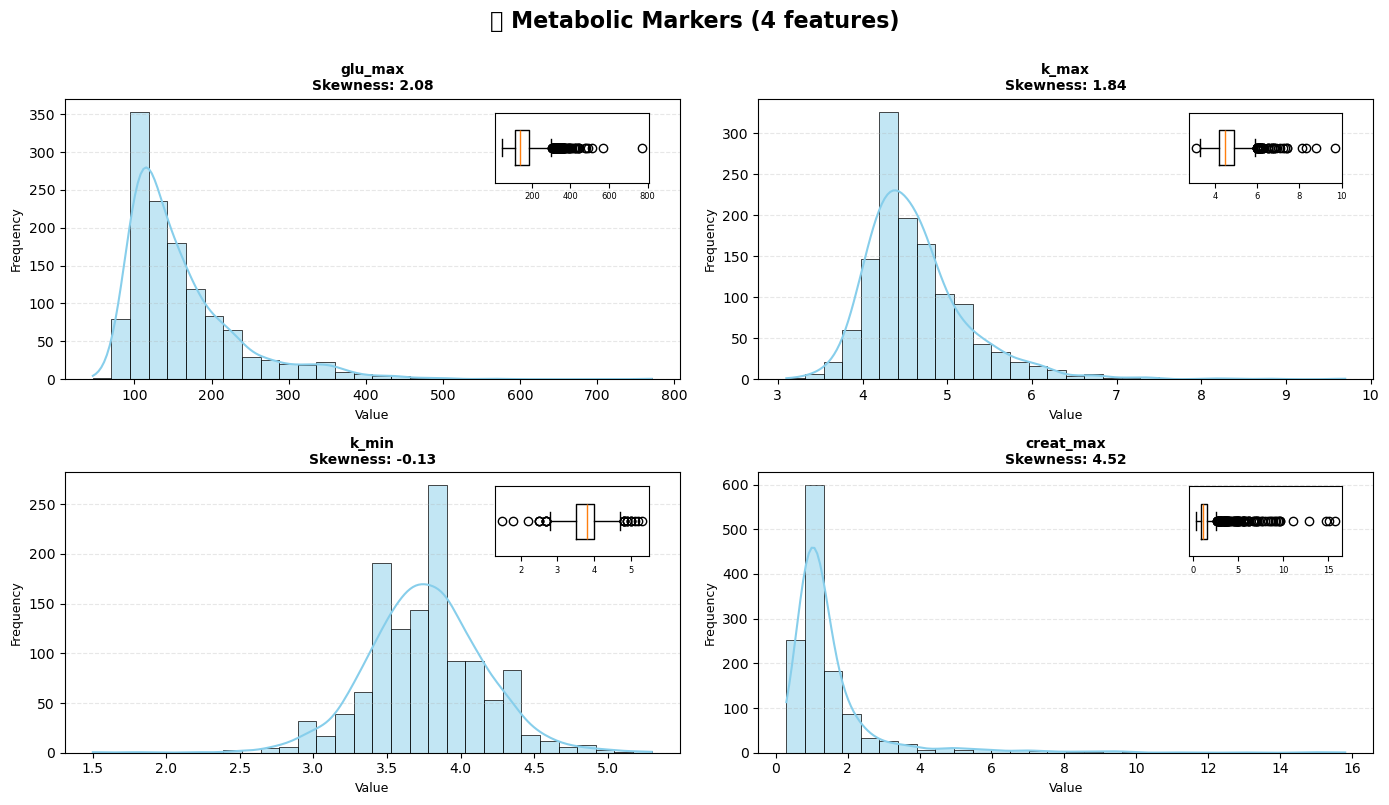


Group: Metabolic Markers

glu_max:
  • N values: 1264
  • Range: [46.00, 771.00]
  • Mean: 161.10 ± 73.79
  • Median: 138.00
  • Skewness: 2.08
  • % NaN: 0.0%

k_max:
  • N values: 1264
  • Range: [3.10, 9.70]
  • Mean: 4.64 ± 0.63
  • Median: 4.50
  • Skewness: 1.84
  • % NaN: 0.0%

k_min:
  • N values: 1264
  • Range: [1.50, 5.30]
  • Mean: 3.76 ± 0.40
  • Median: 3.80
  • Skewness: -0.13
  • % NaN: 0.0%

creat_max:
  • N values: 1264
  • Range: [0.30, 15.80]
  • Mean: 1.56 ± 1.48
  • Median: 1.10
  • Skewness: 4.52
  • % NaN: 0.0%




/tmp/ipykernel_13185/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


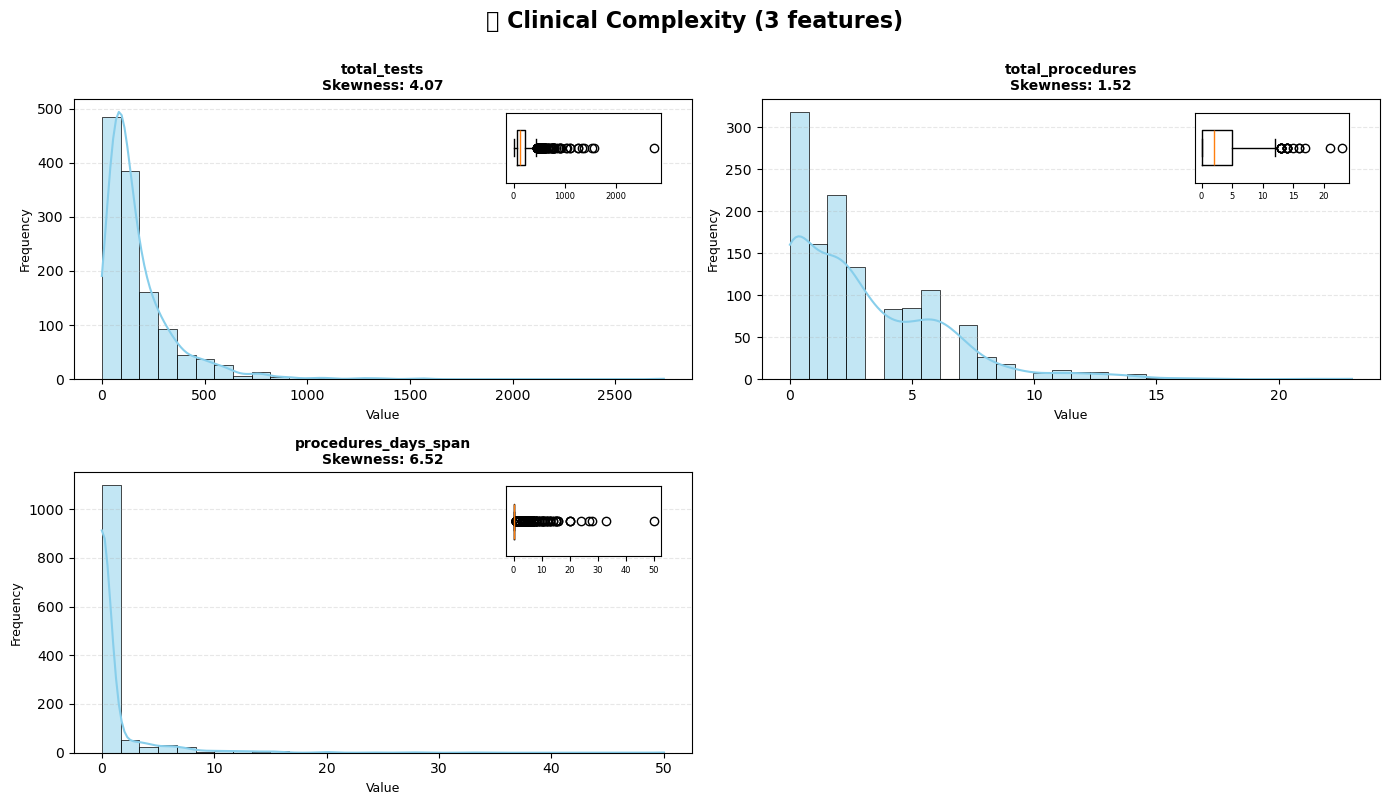


Group: Clinical Complexity

total_tests:
  • N values: 1264
  • Range: [0.00, 2737.00]
  • Mean: 181.07 ± 195.38
  • Median: 117.00
  • Skewness: 4.07
  • % NaN: 0.0%

total_procedures:
  • N values: 1264
  • Range: [0.00, 23.00]
  • Mean: 3.03 ± 3.10
  • Median: 2.00
  • Skewness: 1.52
  • % NaN: 0.0%

procedures_days_span:
  • N values: 1264
  • Range: [0.00, 50.00]
  • Mean: 0.96 ± 3.22
  • Median: 0.00
  • Skewness: 6.52
  • % NaN: 0.0%




/tmp/ipykernel_13185/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


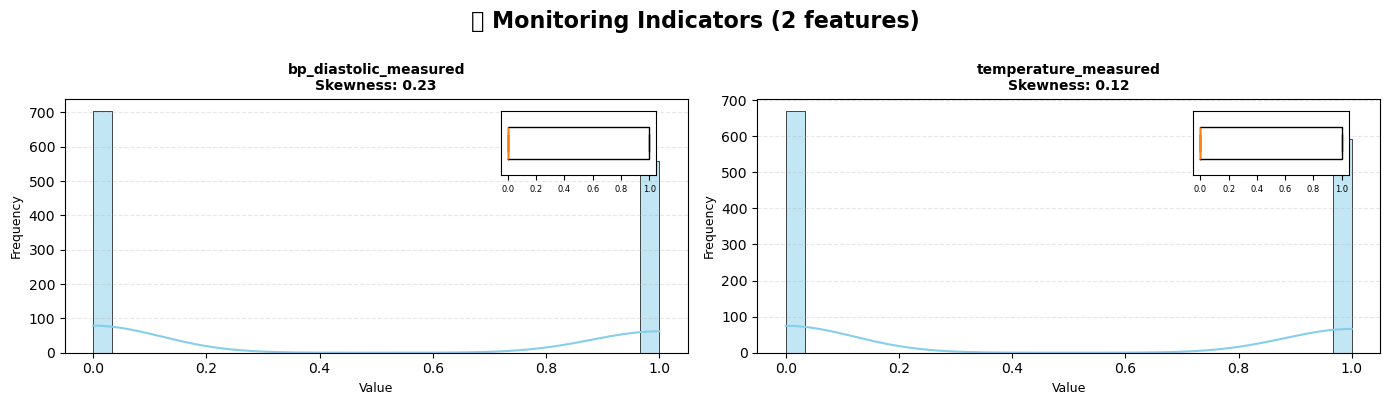


Group: Monitoring Indicators

bp_diastolic_measured:
  • N values: 1264
  • Range: [0.00, 1.00]
  • Mean: 0.44 ± 0.50
  • Median: 0.00
  • Skewness: 0.23
  • % NaN: 0.0%

temperature_measured:
  • N values: 1264
  • Range: [0.00, 1.00]
  • Mean: 0.47 ± 0.50
  • Median: 0.00
  • Skewness: 0.12
  • % NaN: 0.0%




In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

for group_name, features in feature_groups.items():
    existing_features = [f for f in features if f in patient_profiles_clean.columns]
    
    if not existing_features:
        continue
    
    n_cols = 2
    n_rows = (len(existing_features) + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()

    for i, col in enumerate(existing_features):
        ax = axes[i]
        
        data = patient_profiles_clean[col].dropna()
        
        if len(data) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{col}\n(No data)", fontsize=10)
            continue
        
        sns.histplot(data, kde=True, bins=30, ax=ax, color='skyblue', edgecolor='black', linewidth=0.5)
        
        skew_val = skew(data)
        ax_box = ax.inset_axes([0.7, 0.7, 0.25, 0.25])
        ax_box.boxplot(data, vert=False, widths=0.5)
        ax_box.set_yticks([])
        ax_box.set_xlabel('')
        ax_box.tick_params(labelsize=6)
        
        ax.set_title(f"{col}\nSkewness: {skew_val:.2f}", fontsize=10, fontweight='bold')
        ax.set_xlabel('Value', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Hide unused axes
    for j in range(len(existing_features), len(axes)):
        axes[j].axis('off')
    
    # Main title
    plt.suptitle(f'📊 {group_name} ({len(existing_features)} features)', 
                 fontsize=16, fontweight='bold', y=1.00)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*80}")
    print(f"Group: {group_name}")
    print(f"{'='*80}")
    
    # Print statistics for each feature
    for col in existing_features:
        data = patient_profiles_clean[col].dropna()
        if len(data) > 0:
            print(f"\n{col}:")
            print(f"  • N values: {len(data)}")
            print(f"  • Range: [{data.min():.2f}, {data.max():.2f}]")
            print(f"  • Mean: {data.mean():.2f} ± {data.std():.2f}")
            print(f"  • Median: {data.median():.2f}")
            print(f"  • Skewness: {skew(data):.2f}")
            print(f"  • % NaN: {(patient_profiles_clean[col].isna().sum() / len(patient_profiles_clean) * 100):.1f}%")
    
    print(f"\n{'='*80}\n")


In [46]:
skewness = patient_profiles_clean[features_cols].skew()
skewed_features = skewness[abs(skewness) > 1].index.tolist()

print(f"Features with skewness > 1: {len(skewed_features)}")
print("\nSkewness per feature:")
print(skewness[abs(skewness) > 1].sort_values(ascending=False))

Features with skewness > 1: 11

Skewness per feature:
hemodynamic_instability_score    6.907291
procedures_days_span             6.530854
creat_max                        4.527957
total_tests                      4.076682
glu_max                          2.081023
k_max                            1.845524
temperature                      1.741174
total_procedures                 1.518074
respiratory_rate                 1.270675
ecg_abnormality_score            1.176765
respiratory_distress_score       1.027550
dtype: float64


In [47]:
import numpy as np
from scipy.stats import boxcox, yeojohnson
from scipy.stats import skew

def transform_skewed_feature(series, skew_value, method='auto'):
    """
    Advanced feature transformation based on skewness value and data characteristics.
    
    Rules:
    - Skew > 3: Yeo-Johnson (optimal power transformation)
    - 1.5 < Skew <= 3: Box-Cox or sqrt (depends on data range)
    - 1 < Skew <= 1.5: Square root (gentle transformation)
    - |Skew| <= 1: No transformation
    - Skew < -1: Reflect + appropriate transformation
    
    Parameters:
    -----------
    series : pd.Series
        The feature to transform
    skew_value : float
        The skewness value
    method : str
        'auto' (default), 'boxcox', 'yeojohnson', 'sqrt', 'log'
    
    Returns:
    --------
    transformed : pd.Series
        The transformed series
    transformation_name : str
        Description of the transformation applied
    """
    
    transformed = series.copy()
    non_null_mask = transformed.notna()
    non_null_data = transformed[non_null_mask]
    
    if len(non_null_data) == 0:
        return transformed, 'no_transform (all NaN)'
    
    # Calculate data characteristics
    data_min = non_null_data.min()
    data_max = non_null_data.max()
    data_range = data_max - data_min
    has_zeros = (non_null_data == 0).any()
    has_negatives = (non_null_data < 0).any()
    
    
    if skew_value > 1:
        if skew_value > 3 or method == 'yeojohnson':
            try:
                transformed_data, lambda_param = yeojohnson(non_null_data)
                transformed[non_null_mask] = transformed_data
                return transformed, f'yeojohnson (λ={lambda_param:.3f})'
            except:
                pass  # Fallback to next method
        
        if 1.5 < skew_value <= 3:
            if data_max < 100 or method == 'boxcox':
                try:
                    # Handle zeros and negatives for Box-Cox
                    if has_negatives or has_zeros:
                        shift = abs(data_min) + 1
                        data_shifted = non_null_data + shift
                        transformed_data, lambda_param = boxcox(data_shifted)
                        transformed[non_null_mask] = transformed_data
                        return transformed, f'boxcox (λ={lambda_param:.3f}, shift={shift:.2f})'
                    else:
                        transformed_data, lambda_param = boxcox(non_null_data)
                        transformed[non_null_mask] = transformed_data
                        return transformed, f'boxcox (λ={lambda_param:.3f})'
                except:
                    # Fallback to sqrt
                    if has_negatives:
                        shift = abs(data_min) + 1
                        transformed[non_null_mask] = np.sqrt(non_null_data + shift)
                        return transformed, f'sqrt (shifted by {shift:.2f})'
                    else:
                        transformed[non_null_mask] = np.sqrt(non_null_data)
                        return transformed, 'sqrt'
        
        if 1 < skew_value <= 1.5 or method == 'sqrt':
            if has_negatives:
                shift = abs(data_min) + 1
                transformed[non_null_mask] = np.sqrt(non_null_data + shift)
                return transformed, f'sqrt (shifted by {shift:.2f})'
            else:
                transformed[non_null_mask] = np.sqrt(non_null_data)
                return transformed, 'sqrt'
        
        if has_negatives:
            shift = abs(data_min) + 1
            transformed[non_null_mask] = np.log1p(non_null_data + shift)
            return transformed, f'log1p (shifted by {shift:.2f})'
        else:
            transformed[non_null_mask] = np.log1p(non_null_data)
            return transformed, 'log1p'
    
    elif skew_value < -1:
        # Reflect the data
        max_val = non_null_data.max()
        reflected = max_val - non_null_data
        if abs(skew_value) > 3:
            try:
                transformed_data, _ = yeojohnson(reflected)
                transformed[non_null_mask] = transformed_data
                return transformed, 'reflect + yeojohnson'
            except:
                pass
        
        if abs(skew_value) > 1.5:
            transformed[non_null_mask] = np.sqrt(reflected + 1)
            return transformed, 'reflect + sqrt'
        else:
            transformed[non_null_mask] = np.log1p(reflected)
            return transformed, 'reflect + log1p'
    
    else:
        return transformed, 'no_transform (skewness acceptable)'



def transform_all_skewed_features(df, skew_threshold=1.0, exclude_cols=None, method='auto'):
    """
    Apply appropriate transformations to all skewed features in a dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe with features
    skew_threshold : float
        Minimum skewness to trigger transformation (default: 1.0)
    exclude_cols : list
        Columns to exclude from transformation
    method : str
        Transformation method: 'auto', 'boxcox', 'yeojohnson', 'sqrt', 'log'
    
    Returns:
    --------
    df_transformed : pd.DataFrame
        Dataframe with transformed features
    transformation_info : dict
        Information about transformations applied
    """
    
    if exclude_cols is None:
        exclude_cols = []
    
    df_transformed = df.copy()
    transformation_info = {}
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    for col in numeric_cols:
        data = df[col].dropna()
        
        if len(data) == 0:
            continue
        
        original_skew = skew(data)
        
        if abs(original_skew) > skew_threshold:
            # Apply transformation
            transformed_col, transform_name = transform_skewed_feature(
                df[col], 
                original_skew,
                method=method
            )
            
            # Calculate new skewness
            new_skew = skew(transformed_col.dropna())
            improvement = abs(original_skew) - abs(new_skew)
            
            # Update dataframe
            df_transformed[col] = transformed_col
            
            # Store info
            transformation_info[col] = {
                'method': transform_name,
                'original_skew': original_skew,
                'new_skew': new_skew,
                'improvement': improvement
            }
    
    return df_transformed, transformation_info


In [48]:
df_transformed, info = transform_all_skewed_features(
    patient_profiles_clean,
    skew_threshold=1.0,
    exclude_cols=['subject_id'],
    method='auto'
)

In [49]:
for col, details in info.items():
    print(f"{col}: {details['method']} → improvement: {details['improvement']:.2f}")

respiratory_distress_score: sqrt → improvement: 0.89
procedures_days_span: yeojohnson (λ=-3.197) → improvement: 4.90
temperature: boxcox (λ=-0.907) → improvement: 1.54
ecg_abnormality_score: sqrt → improvement: 1.01
k_max: boxcox (λ=-1.969) → improvement: 1.79
glu_max: log1p → improvement: 1.24
respiratory_rate: sqrt → improvement: 0.70
total_procedures: boxcox (λ=0.039, shift=1.00) → improvement: 1.51
total_tests: yeojohnson (λ=0.011) → improvement: 4.07
hemodynamic_instability_score: yeojohnson (λ=-23.221) → improvement: 2.68
creat_max: yeojohnson (λ=-1.908) → improvement: 4.37


We conclude the patient profile creation report by proving that the dataset created is good for clustering by Hopkins score  

In [50]:
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform
from math import isnan

def hopkins_statistic(X):
    X = X.values  # convert to numpy array
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n) 
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
 
    rand_X = sample(range(0, n, 1), m)
 
    ujd = []
    wjd = []
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X[rand_X[j]].reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])
 
    H = sum(ujd) / (sum(ujd) + sum(wjd))
    if isnan(H):
        print(ujd, wjd)
        H = 0
 
    return H

print(f"Hopkins Statistic: {hopkins_statistic(df_transformed.drop(columns=['subject_id']))}")


Hopkins Statistic: 0.8273403721401181


In [51]:
# Save the processed dataset
output_path = 'patient_profiles.csv'
df_transformed.to_csv(Path().resolve().parent / 'Features' / output_path, index=False)